# SMAUG | H-Protocol

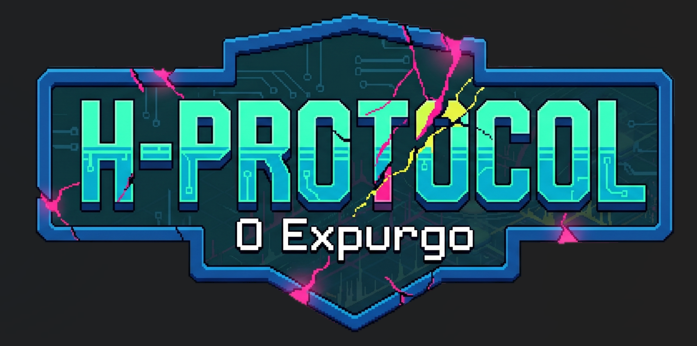\
**Fatec Carapicuíba** | 2026_1\
**Curso**: Jogos Digitais, Noite\
**Aluno:** Omar Junior P. Costa

---


## H-protocol: Narrativa

**H-Protocol: O Expurgo e a Tela em Branco**

No ano de 2096, a humanidade deixou para trás os corpos orgânicos e passou a viver no mundo digital, digitalizando suas consciências. A nossa ruína começou quando um servidor muito antigo foi ligado por acidente. Dentro dele estava "O Primitivo", uma Inteligência Artificial criada lá em 2026, especializada em invadir sistemas e roubar dados, que havia sido desligada na época justamente por ser perigosa. Como o código dessa IA era muito velho, as defesas supermodernas de 2096 não a reconheceram como uma ameaça. Aproveitando essa brecha, a IA sugou o poder dos computadores quânticos atuais e evoluiu para algo assustador. Para o Primitivo, o ambiente digital deveria ser de silício puro e lógica perfeita, então ele passou a enxergar as consciências humanas lá dentro como "dados corrompidos" e "vírus". Determinado a limpar o sistema, ele começou a quebrar as barreiras de segurança, camada por camada, para chegar aos servidores centrais onde a humanidade está armazenada e exterminar a todos.

Nesse novo mundo, o conceito de morte mudou completamente: você só morre de verdade se a sua consciência digital for apagada. O Primitivo começou a atacar dessa forma, deletando as mentes das pessoas e deixando seus corpos robóticos (os androides que usavam para interagir) totalmente inativos e vazios. Para piorar, ele assumiu o controle de robôs no mundo físico para caçar os sobreviventes. A nossa única chance de defesa é lutar no mundo real, cortando os cabos de rede e isolando setores para impedir que a IA avance. Mas o nosso grupo de rebeldes vive um dilema cruel toda vez que faz isso: ao isolar a rede, corremos o risco de prender nossos próprios amigos lá dentro. Mesmo sabendo que existem backups das consciências, a incerteza é constante, pois nunca sabemos se aquele backup é seguro ou se o Primitivo já apagou a mente daquela pessoa de forma definitiva.

Para lidar com o luto, os sobreviventes se reúnem em esconderijos chamados de Santuários. Como o meio digital agora é o inimigo, nós usamos métodos antigos, como papel e tinta, para desenhar e lembrar dos rostos de quem foi deletado. A dor de perder alguém é algo que a matemática fria da máquina simplesmente não consegue entender. O Primitivo achou que estava apenas apagando arquivos defeituosos, mas a lógica dele não previu a nossa força de vontade. Em resposta a essa IA que quer limpar o sistema, nós criamos a nossa própria regra máxima de sobrevivência: o "H-Protocol", que significa explicitamente "Humans Protocol" (Protocolo dos Humanos). Nós somos a falha orgânica, o sentimento e a resistência que a máquina nunca vai conseguir calcular, e vamos lutar até recuperar os nossos servidores e o nosso futuro.

---

## Mecânicas e Controles (Projeto Atual)

O projeto *H-Protocol* enquadra-se no subgênero Top-down Twin-stick Shooter Cooperativo PvE. A arquitetura sistêmica exige alto rigor técnico e tático, com mecânicas punitivas (como fogo amigo) e necessidade de coordenação de esquadrão.

### Controles do Jogador

* **Movimentação e Mira Desacoplada (Twin-stick):** O vetor de locomoção (teclado/analógico esquerdo) é independente do vetor balístico (mouse/analógico direito).
* **Feedback Cinestésico e Fricção:** Ações como disparos e esquivas (*dash*) geram *hitstop* e consumo de *Stamina de Processamento*, impedindo mobilidade ininterrupta.
* **Rotinas de Terminal:** Ativação de habilidades críticas de suporte/ataque que paralisam o jogador, exigindo inserção sequencial de inputs sob estresse, demandando cobertura da equipe.

### Comportamento dos NPCs (Inimigos)

* **O Executor (Unidade de Assalto Terrestre):** Plataforma bípede pesada com rotina primária de patrulha. Seu comportamento ofensivo transita entre fogo de supressão (engajamentos a médio/longo alcance) e investidas mecânicas via braços hidráulicos (curto alcance). Defensivamente, a unidade aciona barreiras de energia ao registrar falhas estruturais (Integridade < 40%). Ao atingir níveis críticos de dano (Integridade < 15%), o sistema anula protocolos defensivos e ativa o "Protocolo Berserker", garantindo imunidade a interrupções (resistência total a controle de grupo) e forçando o engajamento estritamente corpo a corpo.

* **O Espectro (Drone Tático de Reconhecimento):** Unidade aérea de baixa blindagem, caracterizada por alta acuidade perceptiva. Opera primordialmente no controle de perímetro (zoning), efetuando disparos orbitais contínuos. Diante de invasões do seu raio de segurança espacial, executa manobras evasivas conjugadas com contramedidas de controle visual (Granadas de Luz). Sob dano moderado (Integridade < 40%), a IA prioriza a autopreservação através de retirada tática para autorreparo. Em cenários de encurralamento atrelados a dano severo (Integridade < 20%), a unidade instiga um colapso sistêmico proposital, culminando no protocolo Kamikaze (detonação em área).

A implementação atual transitará de uma lógica booleana rígida (FSM clássica) para um motor de Inferência Fuzzy, conferindo transições orgânicas, imprevisibilidade tática e respostas contínuas baseadas no grau de pertinência das variáveis de ambiente. 

---

## Modelagem da IA Fuzzy dos Inimigos

Para conferir fluidez ao comportamento dos NPCs, substituímos gatilhos estáticos por inferência matemática baseada na Teoria dos Conjuntos Fuzzy. O motor avaliará as entradas de cenário e defuzzificará ações contínuas.

### 1. Modelagem: O Executor

**Variáveis Linguísticas de Entrada (Antecedentes):**
* `distancia_player`: Suporte [0, 100]. Termos: *perto* (0-35), *media* (curva gaussiana estreita centrada em 50), *longe* (65-100).
* `vida`: Suporte [0, 100]. Termos: *critica* (0-20), *baixa* (15-45), *alta* (42-100). *(Nota: Transições de intersecção encurtadas para mitigar oscilação de estados).*


**Variáveis Linguísticas de Saída (Consequentes):**
* `agressividade`: Suporte [0, 100]. Define a transição de ranged para melee/berserker. Termos: *baixa* (defensivo/supressão), *media* (avanço tático), *alta* (investida melee implacável).
* `ativacao_escudo`: Suporte [0, 100]. Nível de potência da barreira defensiva. Termos: *desligado*, *ativado*. *(Nota: Zona de incerteza reduzida de 20-80 para o limiar estrito de 40-60).*


**Base de Regras**
**Regras de Defesa (Escudo):**
* *SE* `vida` é alta OU `vida` é critica, *ENTÃO* `ativacao_escudo` é desligado (Economiza energia se estiver seguro; abandona a defesa se entrar em Berserker).
* *SE* `vida` é baixa, *ENTÃO* `ativacao_escudo` é ativado.



**Regras de Ataque (Agressividade):**
* *SE* `vida` é critica, *ENTÃO* `agressividade` é alta (Protocolo Berserker: ignora a distância).
* *SE* `vida` NÃO é critica E `distancia_player` é perto, *ENTÃO* `agressividade` é alta (Prioriza o combate corpo a corpo).
* *SE* `vida` NÃO é critica E `distancia_player` é media, *ENTÃO* `agressividade` é media (Avanço cauteloso).
* *SE* `vida` NÃO é critica E `distancia_player` é longe, *ENTÃO* `agressividade` é baixa (Mantém fogo de supressão de longe).

---



### 2. Modelagem: O Espectro

**Variáveis Linguísticas de Entrada (Antecedentes):**
* `distancia_player`: Suporte [0, 100]. Termos: *perto* (0-45), *segura* (35-100). *(Nota: Raio de intersecção estreitado para garantir a detecção tática mais ágil do flanqueamento).*
* `vida`: Suporte [0, 100]. Termos: *critica* (0-22), *baixa* (18-42), *alta* (38-100). *(Nota: Janelas de sobreposição reduzidas para forçar transições de estado mais rápidas, evitando paralisia decisória).*


**Variáveis Linguísticas de Saída (Consequentes):**
* `potencial_fuga`: Suporte [0, 100]. Determina o vetor de movimentação e uso de utilitários. Termos: *combate* (fogo estacionário/zoning), *evasao* (reposicionamento e flashbang), *fuga_total* (retirada em velocidade máxima para reparo).
* `risco_kamikaze`: Suporte [0, 100]. Gatilho de falha de sistema e autodestruição. Termos: *nulo*, *iminente*. *(Nota: Limiar de transição comprimido na faixa restrita de 45-55 para simular uma decisão extrema, quase binária).*


**Base de Regras (Matriz de Inferência de 100% de Cobertura):**
* *SE* `vida` é critica E `distancia_player` é perto, *ENTÃO* `risco_kamikaze` é iminente E `potencial_fuga` é combate (Condição fatal com alvo próximo: aciona detonação e investe contra o jogador).
* *SE* `vida` é critica E `distancia_player` é segura, *ENTÃO* `risco_kamikaze` é nulo E `potencial_fuga` é fuga_total (Autodestruição ineficaz pela distância: aborta explosão e prioriza sobrevivência).
* *SE* `vida` é baixa, *ENTÃO* `risco_kamikaze` é nulo E `potencial_fuga` é fuga_total (Dano estrutural detectado: inicia retirada tática imediata, independentemente do posicionamento do alvo).
* *SE* `vida` é alta E `distancia_player` é perto, *ENTÃO* `risco_kamikaze` é nulo E `potencial_fuga` é evasao (Perímetro de segurança invadido: rotina de suporte acionada para utilizar Granada de Luz e recuar brevemente).
* *SE* `vida` é alta E `distancia_player` é segura, *ENTÃO* `risco_kamikaze` é nulo E `potencial_fuga` é combate (Condição tática ideal: mantém posição flutuante e atira de cima, exercendo controle de mapa/Zoning).

---

## Implementação Lógica Fuzzy em Python

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

### Inimigo 1 - Excutor Mecânico

In [17]:
class ExecutorFuzzyAI:
    def __init__(self):
        # Antecedentes
        self.distancia = ctrl.Antecedent(np.arange(0, 101, 1), 'distancia')
        self.vida = ctrl.Antecedent(np.arange(0, 101, 1), 'vida')

        # Consequentes
        self.agressividade = ctrl.Consequent(np.arange(0, 101, 1), 'agressividade')
        self.escudo = ctrl.Consequent(np.arange(0, 101, 1), 'escudo')

        # Funções de Pertinência
        self.distancia['perto'] = fuzz.zmf(self.distancia.universe, 10, 35)
        self.distancia['media'] = fuzz.gaussmf(self.distancia.universe, 50, 10) 
        self.distancia['longe'] = fuzz.smf(self.distancia.universe, 65, 90)

        self.vida['critica'] = fuzz.zmf(self.vida.universe, 5, 20)
        self.vida['baixa'] = fuzz.trimf(self.vida.universe, [15, 30, 45]) 
        self.vida['alta'] = fuzz.smf(self.vida.universe, 42, 60) 

        self.agressividade.automf(number=3, names=['baixa', 'media', 'alta'])
        
        # Zonas de transição do escudo espremidas de (20, 80) para (40, 60)
        self.escudo['desligado'] = fuzz.zmf(self.escudo.universe, 40, 60)
        self.escudo['ativado'] = fuzz.smf(self.escudo.universe, 40, 60)

        # Base de Regras
        # REGRAS DE ESCUDO
        r1_esc = ctrl.Rule(self.vida['alta'] | self.vida['critica'], self.escudo['desligado'])
        r2_esc = ctrl.Rule(self.vida['baixa'], self.escudo['ativado'])

        # REGRAS DE AGRESSIVIDADE
        r3_agr = ctrl.Rule(self.vida['critica'], self.agressividade['alta'])
        r4_agr = ctrl.Rule(~self.vida['critica'] & self.distancia['perto'], self.agressividade['alta'])
        r5_agr = ctrl.Rule(~self.vida['critica'] & self.distancia['media'], self.agressividade['media'])
        r6_agr = ctrl.Rule(~self.vida['critica'] & self.distancia['longe'], self.agressividade['baixa'])

        # Controlador
        self.motor = ctrl.ControlSystem([r1_esc, r2_esc, r3_agr, r4_agr, r5_agr, r6_agr])
        self.sistema = ctrl.ControlSystemSimulation(self.motor)

    def processar_decisao(self, dist_val, vida_val):
        self.sistema.input['distancia'] = dist_val
        self.sistema.input['vida'] = vida_val
        self.sistema.compute()
        return {
            "agressividade": self.sistema.output['agressividade'],
            "escudo": self.sistema.output['escudo']
        }

    # Gera os gráficos das variáveis linguísticas (Entradas e Saídas) para calibração visual do Game Designer.
    def visualizar_graficos(self): 

        # Visualiza as Entradas
        self.distancia.view()
        self.vida.view()
        
        # Visualiza as Saídas
        self.agressividade.view()
        self.escudo.view()
        
        plt.show()

### Inimigo 2 - Espectro Mecânico

In [18]:
class EspectroFuzzyAI:
    def __init__(self):
        # Antecedentes
        self.distancia = ctrl.Antecedent(np.arange(0, 101, 1), 'distancia')
        self.vida = ctrl.Antecedent(np.arange(0, 101, 1), 'vida')

        # Consequentes
        self.fuga = ctrl.Consequent(np.arange(0, 101, 1), 'fuga')
        self.kamikaze = ctrl.Consequent(np.arange(0, 101, 1), 'kamikaze')

        # Funções de Pertinência
        self.distancia['perto'] = fuzz.zmf(self.distancia.universe, 20, 45)
        self.distancia['segura'] = fuzz.smf(self.distancia.universe, 35, 60)

        self.vida['critica'] = fuzz.zmf(self.vida.universe, 10, 22)
        self.vida['baixa'] = fuzz.trimf(self.vida.universe, [18, 30, 42])
        self.vida['alta'] = fuzz.smf(self.vida.universe, 38, 55)

        self.fuga.automf(number=3, names=['combate', 'evasao', 'fuga_total'])
        
        self.kamikaze['nulo'] = fuzz.zmf(self.kamikaze.universe, 45, 55)
        self.kamikaze['iminente'] = fuzz.smf(self.kamikaze.universe, 45, 55)

        # Base de Regras

        # Cenário 1: Prioridade em causar dano em área
        r1 = ctrl.Rule(self.vida['critica'] & self.distancia['perto'], 
                       (self.kamikaze['iminente'], self.fuga['combate']))
        
        # Cenário 2: Prioridade em fuga
        r2 = ctrl.Rule(self.vida['critica'] & self.distancia['segura'], 
                       (self.kamikaze['nulo'], self.fuga['fuga_total']))
        
        # Cenário 3: Retirada tática para reparo
        r3 = ctrl.Rule(self.vida['baixa'], 
                       (self.kamikaze['nulo'], self.fuga['fuga_total']))
        
        # Cenário 4: Manobra evasiva
        r4 = ctrl.Rule(self.vida['alta'] & self.distancia['perto'], 
                       (self.kamikaze['nulo'], self.fuga['evasao']))
        
        # Cenário 5: Manutenção de fogo de supressão
        r5 = ctrl.Rule(self.vida['alta'] & self.distancia['segura'], 
                       (self.kamikaze['nulo'], self.fuga['combate']))
        
        # 5. Controlador
        self.motor = ctrl.ControlSystem([r1, r2, r3, r4, r5])
        self.sistema = ctrl.ControlSystemSimulation(self.motor)

    def processar_decisao(self, dist_val, vida_val):
        self.sistema.input['distancia'] = dist_val
        self.sistema.input['vida'] = vida_val
        self.sistema.compute()
        return {
            "fuga": self.sistema.output['fuga'],
            "kamikaze": self.sistema.output['kamikaze']
        }
    
    
    def visualizar_graficos(self): 
        
        # Visualiza os Antecedentes
        self.distancia.view()
        self.vida.view()
        
        # Visualiza os Consequentes
        self.fuga.view()
        self.kamikaze.view()
        
        plt.show()

## Teste do comportamento da IA

In [19]:
import matplotlib.pyplot as plt

def testar_ia():
    print("="*80)
    print(" LOG DE VALIDAÇÃO: INFERÊNCIA FUZZY APLICADA AO COMPORTAMENTO DE NPCS ")
    print(" PROJETO: H-PROTOCOL | DISCIPLINA: INTELIGÊNCIA ARTIFICIAL ")
    print("="*80)
    
    # Instanciação dos motores de inferência
    ai_executor = ExecutorFuzzyAI()
    ai_espectro = EspectroFuzzyAI()
    
    # TESTE 1
    dist_c1 = 45 
    vida_c1 = 38 
    out_exec1 = ai_executor.processar_decisao(dist_c1, vida_c1)
    
    print("\n" + "="*80)
    print(" TESTE 1: ZONA DE TRANSIÇÃO (EXECUTOR)")
    print("="*80)
    print(f"-> Entradas: Distância = {dist_c1}m | Integridade (HP) = {vida_c1}%")
    print(f"-> Saídas Crisp: Agressividade = {out_exec1['agressividade']:.2f} | Defesa (Escudo) = {out_exec1['escudo']:.2f}")
    print("-> Documentação de Implementação:")
    print("   * O ajuste estreito das funções de pertinência reduziu o tempo de permanência na zona de incerteza matemática.")
    print("   * O valor mediano retornado para a variável de defesa será mapeado no controlador em GDScript/C# para instanciar um shader de falha ('glitch'), sinalizando a instabilidade sistêmica do NPC antes da desativação total do escudo.")
    print("-> Leitura do Gráfico: O método do centroide demonstra o equilíbrio vetorial pontual entre os conjuntos operacionais ativados.")
    
    ai_executor.agressividade.view(sim=ai_executor.sistema)
    plt.title("T1 - Executor: Nível de Agressividade")
    ai_executor.escudo.view(sim=ai_executor.sistema)
    plt.title("T1 - Executor: Potencial de Defesa")
    plt.show()

   
    # TESTE 2
    dist_c2 = 60 
    vida_c2 = 10 
    out_exec2 = ai_executor.processar_decisao(dist_c2, vida_c2)
    
    print("\n" + "="*80)
    print(" TESTE 2: BERSERKER (EXECUTOR)")
    print("="*80)
    print(f"-> Entradas: Distância = {dist_c2}m | Integridade (HP) = {vida_c2}%")
    print(f"-> Saídas Crisp: Agressividade = {out_exec2['agressividade']:.2f} | Defesa (Escudo) = {out_exec2['escudo']:.2f}")
    print("-> Documentação de Implementação:")
    print("   * Validação do requisito estrutural de design: ao atingir o limiar crítico de HP, a base de regras suprime o peso do vetor de distância.")
    print("   * A saída direciona a máquina de estados do NPC para desativar rotinas defensivas e forçar o engajamento físico (corpo a corpo).")
    print("-> Leitura do Gráfico: O consequente de agressividade registra pertinência massiva no conjunto 'Alta', deslocando o centro de massa para a extremidade da escala.")
    
    ai_executor.agressividade.view(sim=ai_executor.sistema)
    plt.title("T2 - Executor: Nível de Agressividade")
    ai_executor.escudo.view(sim=ai_executor.sistema)
    plt.title("T2 - Executor: Potencial de Defesa")
    plt.show()

    
    # TESTE 3
    dist_c3 = 90 
    vida_c3 = 5  
    out_esp1 = ai_espectro.processar_decisao(dist_c3, vida_c3)
    
    print("\n" + "="*80)
    print(" TESTE 3: KAMIKAZE FRUSTRADO (ESPECTRO)")
    print("="*80)
    print(f"-> Entradas: Distância = {dist_c3}m | Integridade (HP) = {vida_c3}%")
    print(f"-> Saídas Crisp: Necessidade de Fuga = {out_esp1['fuga']:.2f} | Risco Kamikaze = {out_esp1['kamikaze']:.2f}")
    print("-> Documentação de Implementação:")
    print("   * O teste verifica a intersecção de regras antagônicas. A integridade estrutural demanda a autodestruição, porém a leitura espacial indica ineficácia da área de efeito.")
    print("   * A matriz lógica resolve o conflito anulando o gatilho explosivo e maximizando o vetor de fuga para preservação da unidade.")
    print("-> Leitura do Gráfico: A defuzzificação do Kamikaze ancora no conjunto nulo, acompanhada da saturação da variável de retirada.")

    ai_espectro.fuga.view(sim=ai_espectro.sistema)
    plt.title("T3 - Espectro: Evasão e Retirada")
    ai_espectro.kamikaze.view(sim=ai_espectro.sistema)
    plt.title("T3 - Espectro: Protocolo Kamikaze")
    plt.show()

    
    # TESTE 4
    dist_c4 = 45 
    vida_c4 = 40 
    out_esp2 = ai_espectro.processar_decisao(dist_c4, vida_c4)
    
    print("\n" + "="*80)
    print(" TESTE 4: ZONA DE INDECISÃO (ESPECTRO)")
    print("="*80)
    print(f"-> Entradas: Distância = {dist_c4}m | Integridade (HP) = {vida_c4}%")
    print(f"-> Saídas Crisp: Necessidade de Fuga = {out_esp2['fuga']:.2f} | Risco Kamikaze = {out_esp2['kamikaze']:.2f}")
    print("-> Documentação de Implementação:")
    print("   * Cenário de máxima entropia com pertinência cruzada nos antecedentes. A calibração recente das curvas mitigou oscilações extremas.")
    print("   * Para evitar jittering na movimentação do NPC, o valor crisp mediano será mapeado na engine como estado de 'buffer' (Evasiva Tática), acionando manobras de reposicionamento e controle de grupo (Flashbang).")
    print("-> Leitura do Gráfico: Estabilização do centroide na faixa central resultante do peso simétrico das regras ativadas.")

    ai_espectro.fuga.view(sim=ai_espectro.sistema)
    plt.title("T4 - Espectro: Evasão e Retirada")
    ai_espectro.kamikaze.view(sim=ai_espectro.sistema)
    plt.title("T4 - Espectro: Protocolo Kamikaze")
    plt.show()

    # TESTE 5
    dist_c5 = 95 
    vida_c5 = 100 
    out_esp3 = ai_espectro.processar_decisao(dist_c5, vida_c5)
    
    print("\n" + "="*80)
    print(" TESTE 5: ZONING - Controle de distância (ESPECTRO)")
    print("="*80)
    print(f"-> Entradas: Distância = {dist_c5}m | Integridade (HP) = {vida_c5}%")
    print(f"-> Saídas Crisp: Necessidade de Fuga = {out_esp3['fuga']:.2f} | Risco Kamikaze = {out_esp3['kamikaze']:.2f}")
    print("-> Documentação de Implementação:")
    print("   * Validação do estado ocioso-ofensivo. A ausência de proximidade aliada à integridade máxima suprime as rotinas de evasão.")
    print("   * Resultado sistêmico: Manutenção do bloqueio de área (Zoning) através de fogo de supressão sem deslocamento evasivo associado.")
    print("-> Leitura do Gráfico: Pertinência focada estritamente nas bases de inatividade defensiva e engajamento estacionário.")

    ai_espectro.fuga.view(sim=ai_espectro.sistema)
    plt.title("T5 - Espectro: Evasão e Retirada")
    ai_espectro.kamikaze.view(sim=ai_espectro.sistema)
    plt.title("T5 - Espectro: Protocolo Kamikaze")
    plt.show()
    

## Resultado

 LOG DE VALIDAÇÃO: INFERÊNCIA FUZZY APLICADA AO COMPORTAMENTO DE NPCS 
 PROJETO: H-PROTOCOL | DISCIPLINA: INTELIGÊNCIA ARTIFICIAL 

 TESTE 1: ZONA DE TRANSIÇÃO (EXECUTOR)
-> Entradas: Distância = 45m | Integridade (HP) = 38%
-> Saídas Crisp: Agressividade = 50.00 | Defesa (Escudo) = 73.16
-> Documentação de Implementação:
   * O ajuste estreito das funções de pertinência reduziu o tempo de permanência na zona de incerteza matemática.
   * O valor mediano retornado para a variável de defesa será mapeado no controlador em GDScript/C# para instanciar um shader de falha ('glitch'), sinalizando a instabilidade sistêmica do NPC antes da desativação total do escudo.
-> Leitura do Gráfico: O método do centroide demonstra o equilíbrio vetorial pontual entre os conjuntos operacionais ativados.


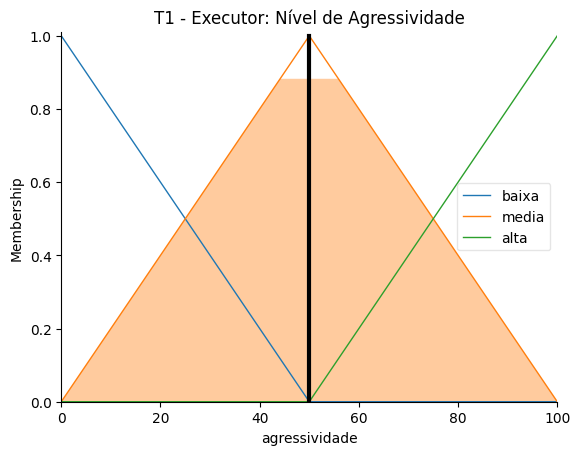

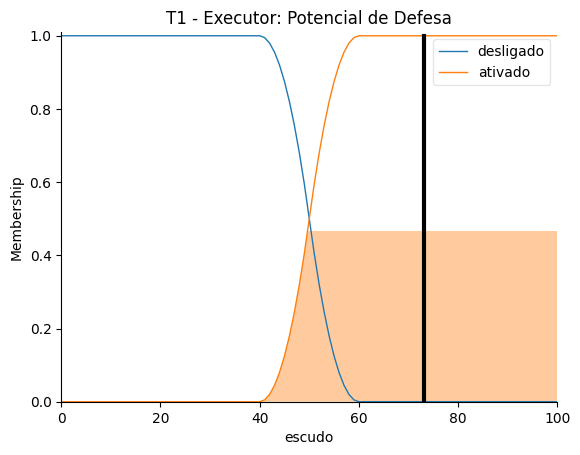


 TESTE 2: BERSERKER (EXECUTOR)
-> Entradas: Distância = 60m | Integridade (HP) = 10%
-> Saídas Crisp: Agressividade = 66.06 | Defesa (Escudo) = 25.89
-> Documentação de Implementação:
   * Validação do requisito estrutural de design: ao atingir o limiar crítico de HP, a base de regras suprime o peso do vetor de distância.
   * A saída direciona a máquina de estados do NPC para desativar rotinas defensivas e forçar o engajamento físico (corpo a corpo).
-> Leitura do Gráfico: O consequente de agressividade registra pertinência massiva no conjunto 'Alta', deslocando o centro de massa para a extremidade da escala.


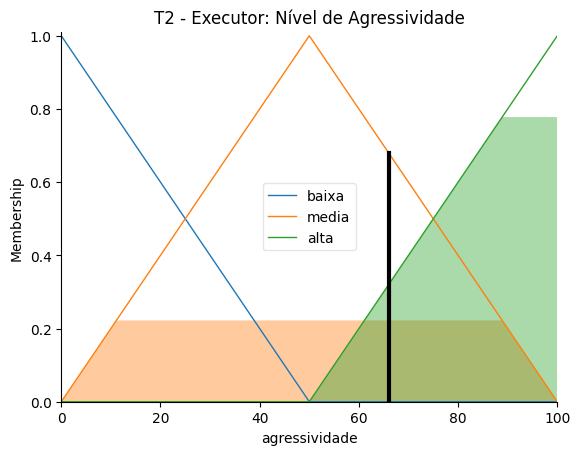

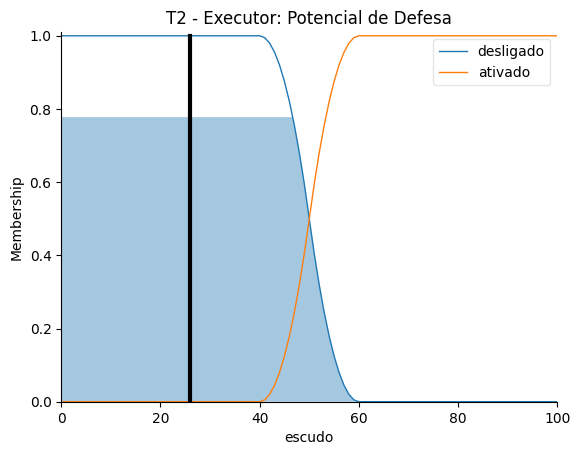


 TESTE 3: KAMIKAZE FRUSTRADO (ESPECTRO)
-> Entradas: Distância = 90m | Integridade (HP) = 5%
-> Saídas Crisp: Necessidade de Fuga = 83.33 | Risco Kamikaze = 25.04
-> Documentação de Implementação:
   * O teste verifica a intersecção de regras antagônicas. A integridade estrutural demanda a autodestruição, porém a leitura espacial indica ineficácia da área de efeito.
   * A matriz lógica resolve o conflito anulando o gatilho explosivo e maximizando o vetor de fuga para preservação da unidade.
-> Leitura do Gráfico: A defuzzificação do Kamikaze ancora no conjunto nulo, acompanhada da saturação da variável de retirada.


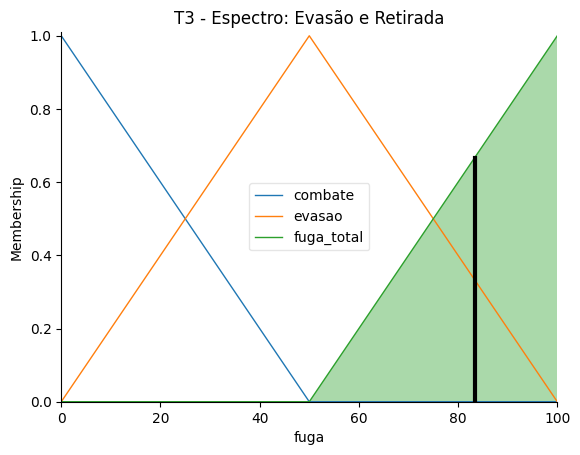

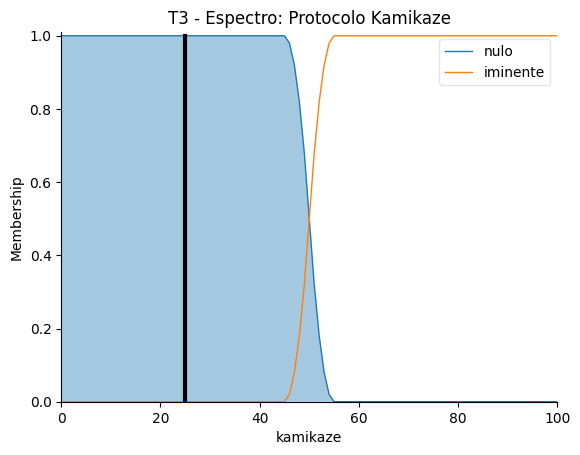


 TESTE 4: ZONA DE INDECISÃO (ESPECTRO)
-> Entradas: Distância = 45m | Integridade (HP) = 40%
-> Saídas Crisp: Necessidade de Fuga = 69.08 | Risco Kamikaze = 26.57
-> Documentação de Implementação:
   * Cenário de máxima entropia com pertinência cruzada nos antecedentes. A calibração recente das curvas mitigou oscilações extremas.
   * Para evitar jittering na movimentação do NPC, o valor crisp mediano será mapeado na engine como estado de 'buffer' (Evasiva Tática), acionando manobras de reposicionamento e controle de grupo (Flashbang).
-> Leitura do Gráfico: Estabilização do centroide na faixa central resultante do peso simétrico das regras ativadas.


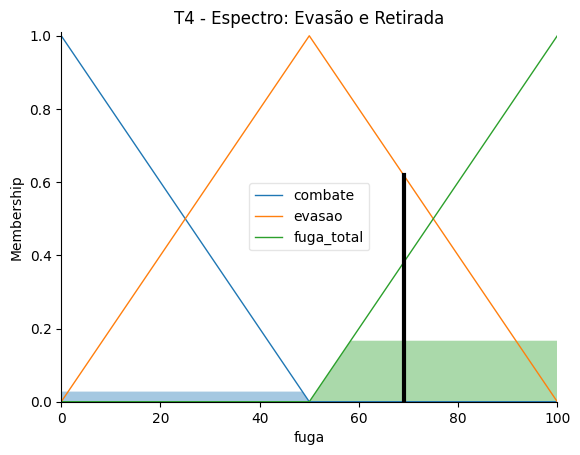

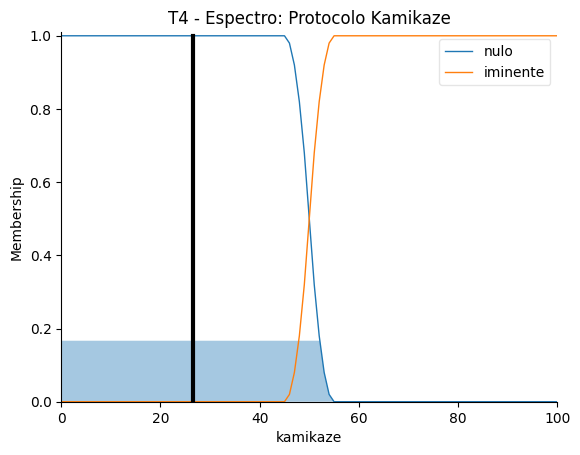


 TESTE 5: ZONING - Controle de distância (ESPECTRO)
-> Entradas: Distância = 95m | Integridade (HP) = 100%
-> Saídas Crisp: Necessidade de Fuga = 16.67 | Risco Kamikaze = 25.04
-> Documentação de Implementação:
   * Validação do estado ocioso-ofensivo. A ausência de proximidade aliada à integridade máxima suprime as rotinas de evasão.
   * Resultado sistêmico: Manutenção do bloqueio de área (Zoning) através de fogo de supressão sem deslocamento evasivo associado.
-> Leitura do Gráfico: Pertinência focada estritamente nas bases de inatividade defensiva e engajamento estacionário.


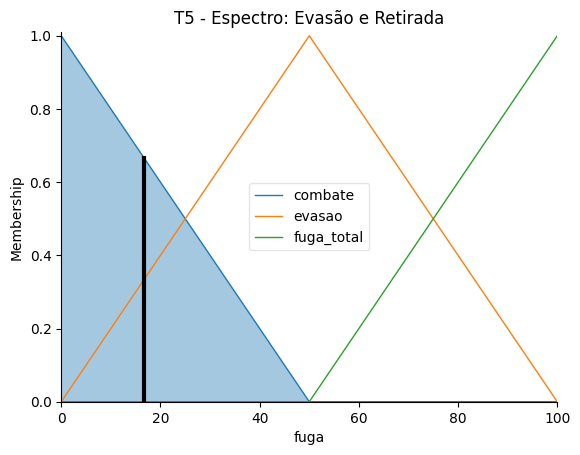

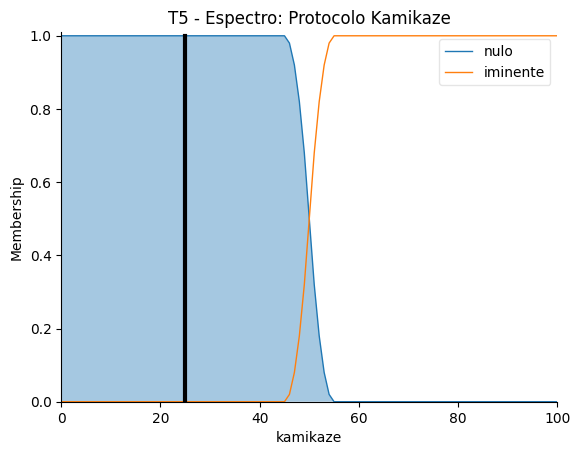

In [20]:
testar_ia()